In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5.0,5.0,100)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y,-y])
x = np.hstack([x,-x])

In [11]:
x1 = np.linspace(-5.0,5.0,100)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1,-y1])
x1 = np.hstack([x1,-x1])

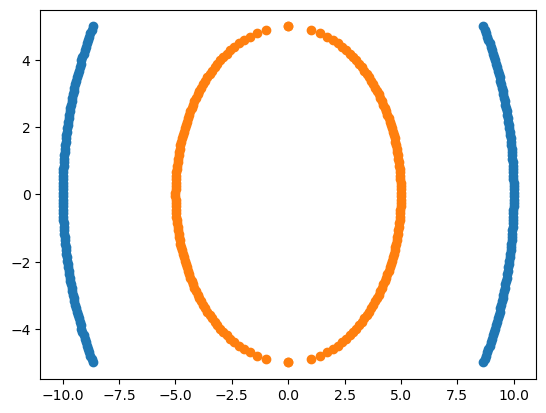

In [12]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [17]:
import pandas as pd
df1 = pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2 = pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)
df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [18]:
df['X1_square'] = df['X1']**2
df['X2_square'] = df['X2']**2
df['X1*X2'] = df['X1']*df['X2']
df.head()

,X1,X2,Y,X1_square,X2_square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [19]:
# independent and dependent features
X = df[['X1_square','X2_square','X1*X2']]
y = df[['Y']]

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [21]:
X_train.head()

,X1_square,X2_square,X1*X2
247,24.936231,0.063769,-1.261015
110,84.080706,15.919294,-36.585591
16,88.549638,11.450362,-31.842196
66,97.222222,2.777778,16.433555
153,99.875013,0.124987,3.533143


In [23]:
%matplotlib inline

!pip install plotly

In [24]:
df.head()

,X1,X2,Y,X1_square,X2_square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [25]:
import plotly.express as px
fig = px.scatter_3d(df, x ='X1_square', y = 'X2_square', z = 'X1*X2', color='Y')

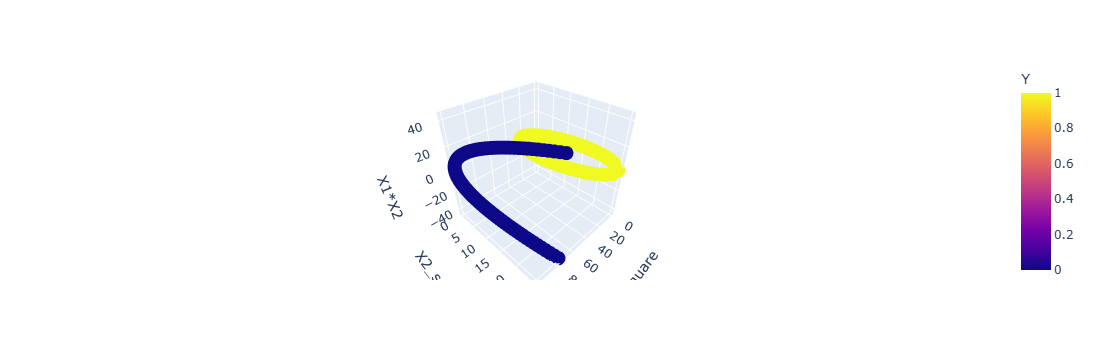

In [26]:
fig.show()
plt.show()

In [27]:
# Kernel = Radial basis functional kernel(rbf)

In [29]:
X = df.iloc[:,0:2]
y = df.Y

In [30]:
X.head()

,X1,X2
0,8.660254,-5.00000
1,8.717792,-4.89899
2,8.773790,-4.79798
3,8.828277,-4.69697
4,8.881281,-4.59596


In [32]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [34]:
classifier = SVC(kernel='rbf')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_pred,y_test))

1.0


In [35]:
# Kernel = ploynomial(poly)

In [36]:
classifier = SVC(kernel='poly')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_pred,y_test))

0.69


In [37]:
# kernel = sigmoid

In [38]:
classifier = SVC(kernel='sigmoid')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_pred,y_test))

0.56
